In [1]:
import torch
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2")

ModuleNotFoundError: No module named 'transformer_lens'

In [2]:
!pip install transformer_lens

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.7 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12526 sha256=7ea24107b28b2a42433216281db983a2821b45d1c665976f5c21b83f4ea22664
  Stored in directory: /root/.cache/pip/wheels/f6/6e/1a/710143d0e50e827ae5b60a47a6d43d715cf1c6e35881a05530
Successfully built transformers-stream-generator


In [3]:
import torch
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2")

/tmp/ipykernel_6769/1659195434.py:4: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained("gpt2")


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

...

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer


In [4]:
prompts = [
    "The capital of France is",      # I predict: " Paris"
    "2 + 2 =",                        # I predict: " 4"
    "The opposite of hot is",         # I predict: " cold"
    "Once upon a",                    # I predict: " time"
]


In [5]:
prompt = prompts[0]
tokens = model.to_tokens(prompt)
logits, cache = model.run_with_cache(tokens)

print(model.to_string(tokens))

['<|endoftext|>The capital of France is']


In [6]:
accumulated_residual, labels = cache.accumulated_resid(
    layer=-1, incl_mid=True, return_labels=True
)

scaled_residual = cache.apply_ln_to_stack(accumulated_residual, layer=-1)
logits_per_layer = scaled_residual @ model.W_U

last_token_logits = logits_per_layer[:, 0, -1, :]
top_tokens = last_token_logits.argmax(dim=-1)

for layer_name, tok_id in zip(labels, top_tokens):
    print(f"{layer_name}: predicts '{model.to_string(tok_id)}'")

0_pre: predicts ' destro'
0_mid: predicts ' clear'
1_pre: predicts ' unlikely'
1_mid: predicts ' unlikely'
2_pre: predicts ' unlikely'
2_mid: predicts ' unlikely'
3_pre: predicts ' now'
3_mid: predicts ' now'
4_pre: predicts ' now'
4_mid: predicts ' now'
5_pre: predicts ' now'
5_mid: predicts ' now'
6_pre: predicts ' now'
6_mid: predicts ' now'
7_pre: predicts ' officially'
7_mid: predicts ' officially'
8_pre: predicts ' now'
8_mid: predicts ' officially'
9_pre: predicts ' reportedly'
9_mid: predicts ' officially'
10_pre: predicts ' reeling'
10_mid: predicts ' reeling'
11_pre: predicts ' reeling'
11_mid: predicts ' reeling'
final_post: predicts ' reeling'


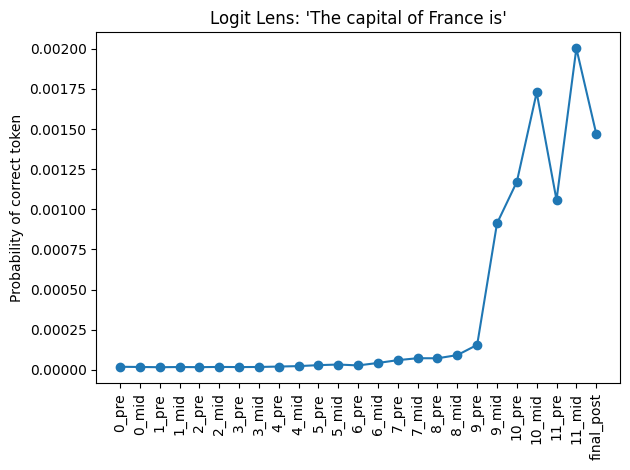

In [7]:
import matplotlib.pyplot as plt

correct_token_id = model.to_single_token(" Paris")   # change this per prompt below
probs_per_layer = last_token_logits.softmax(dim=-1)[:, correct_token_id]

plt.plot(probs_per_layer.detach().numpy(), marker='o')
plt.xticks(range(len(labels)), labels, rotation=90)
plt.ylabel("Probability of correct token")
plt.title(f"Logit Lens: '{prompt}'")
plt.tight_layout()
plt.show()

In [13]:
prompt = prompts[1]
tokens = model.to_tokens(prompt)
logits, cache = model.run_with_cache(tokens)

print(model.to_string(tokens))

['<|endoftext|>2 + 2 =']


In [14]:
accumulated_residual, labels = cache.accumulated_resid(
    layer=-1, incl_mid=True, return_labels=True
)

scaled_residual = cache.apply_ln_to_stack(accumulated_residual, layer=-1)
logits_per_layer = scaled_residual @ model.W_U

last_token_logits = logits_per_layer[:, 0, -1, :]
top_tokens = last_token_logits.argmax(dim=-1)

for layer_name, tok_id in zip(labels, top_tokens):
    print(f"{layer_name}: predicts '{model.to_string(tok_id)}'")

0_pre: predicts ' ='
0_mid: predicts '++++++++++++++++'
1_pre: predicts '========'
1_mid: predicts '========'
2_pre: predicts '========'
2_mid: predicts '========'
3_pre: predicts '========'
3_mid: predicts '========'
4_pre: predicts '========'
4_mid: predicts '========'
5_pre: predicts '========'
5_mid: predicts '========'
6_pre: predicts '========'
6_mid: predicts '========'
7_pre: predicts '========'
7_mid: predicts '========'
8_pre: predicts '========'
8_mid: predicts '========'
9_pre: predicts '========'
9_mid: predicts ' 0'
10_pre: predicts ' 2'
10_mid: predicts ' 2'
11_pre: predicts ' 2'
11_mid: predicts ' 2'
final_post: predicts ' 2'


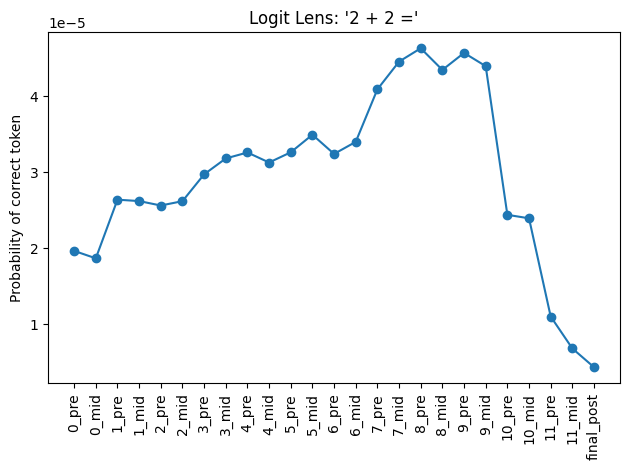

In [15]:
import matplotlib.pyplot as plt

correct_token_id = model.to_single_token(" Paris")   # change this per prompt below
probs_per_layer = last_token_logits.softmax(dim=-1)[:, correct_token_id]

plt.plot(probs_per_layer.detach().numpy(), marker='o')
plt.xticks(range(len(labels)), labels, rotation=90)
plt.ylabel("Probability of correct token")
plt.title(f"Logit Lens: '{prompt}'")
plt.tight_layout()
plt.show()

In [10]:
prompt = prompts[2]
tokens = model.to_tokens(prompt)
logits, cache = model.run_with_cache(tokens)

print(model.to_string(tokens))

['<|endoftext|>The opposite of hot is']


In [11]:
accumulated_residual, labels = cache.accumulated_resid(
    layer=-1, incl_mid=True, return_labels=True
)

scaled_residual = cache.apply_ln_to_stack(accumulated_residual, layer=-1)
logits_per_layer = scaled_residual @ model.W_U

last_token_logits = logits_per_layer[:, 0, -1, :]
top_tokens = last_token_logits.argmax(dim=-1)

for layer_name, tok_id in zip(labels, top_tokens):
    print(f"{layer_name}: predicts '{model.to_string(tok_id)}'")

0_pre: predicts ' destro'
0_mid: predicts 'cer'
1_pre: predicts ' unlikely'
1_mid: predicts ' unlikely'
2_pre: predicts ' unlikely'
2_mid: predicts ' currently'
3_pre: predicts ' now'
3_mid: predicts 'cussion'
4_pre: predicts ' now'
4_mid: predicts 'cussion'
5_pre: predicts ' now'
5_mid: predicts ' sometimes'
6_pre: predicts 'ometric'
6_mid: predicts ' sometimes'
7_pre: predicts ' sometimes'
7_mid: predicts ' sometimes'
8_pre: predicts ' sometimes'
8_mid: predicts ' cooler'
9_pre: predicts ' cooler'
9_mid: predicts ' cooler'
10_pre: predicts ' cooler'
10_mid: predicts ' cooler'
11_pre: predicts ' cooler'
11_mid: predicts ' cooler'
final_post: predicts ' cooler'


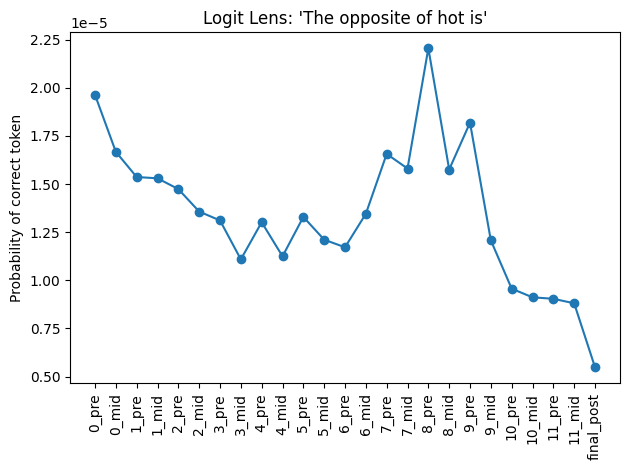

In [12]:
import matplotlib.pyplot as plt

correct_token_id = model.to_single_token(" Paris")   # change this per prompt below
probs_per_layer = last_token_logits.softmax(dim=-1)[:, correct_token_id]

plt.plot(probs_per_layer.detach().numpy(), marker='o')
plt.xticks(range(len(labels)), labels, rotation=90)
plt.ylabel("Probability of correct token")
plt.title(f"Logit Lens: '{prompt}'")
plt.tight_layout()
plt.show()